<a href="https://colab.research.google.com/github/Jashwanth248/ai-hw-Spring-2026-nn/blob/main/MNIST%20Recognition%20by%20NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from datasets import load_dataset
import numpy as np
import torchvision.transforms as transforms

Load MNIST

In [ ]:
dataset = load_dataset("ylecun/mnist")

train_ds = dataset["train"]
test_ds = dataset["test"]

Convert to Tensor

In [ ]:
def transform(example):
    image = np.array(example["image"]) / 255.0
    image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
    label = torch.tensor(example["label"], dtype=torch.long)
    return {"image": image, "label": label}

train_ds = train_ds.map(transform)
test_ds = test_ds.map(transform)

train_ds.set_format(type="torch", columns=["image", "label"])
test_ds.set_format(type="torch", columns=["image", "label"])

DataLoad

In [7]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=1000, shuffle=False)

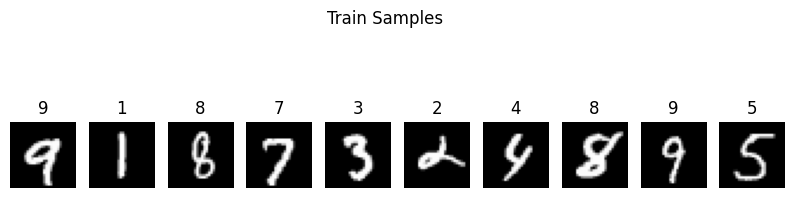

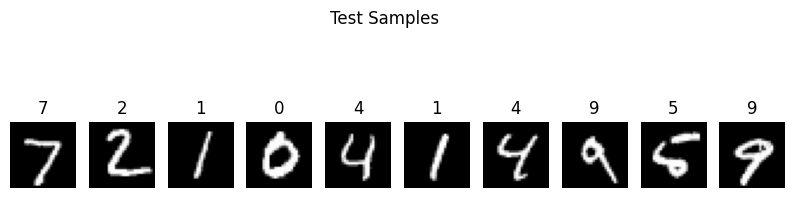

In [8]:
import matplotlib.pyplot as plt

def show_images(loader, title):
    batch = next(iter(loader))
    images = batch["image"][:10]
    labels = batch["label"][:10]

    plt.figure(figsize=(10,3))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(labels[i].item())
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

show_images(train_loader, "Train Samples")
show_images(test_loader, "Test Samples")

Data Augmentation

In [9]:
augment = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1))
])

MLP Model

In [10]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

CNN Model

In [11]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

Transformer Model

In [12]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed_dim = 64

        self.patch_embed = nn.Conv2d(1, self.embed_dim, kernel_size=7, stride=7)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embed_dim,
            nhead=4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(self.embed_dim, 10)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).permute(0, 2, 1)

        x = self.transformer(x)
        x = x.mean(dim=1)

        return self.fc(x)

Train Function (WITH AUGMENTATION)

In [13]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for batch in loader:
        data = batch["image"]
        target = batch["label"]


        data = torch.stack([augment(img) for img in data])

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

Test Function

In [14]:
def test(model, loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for batch in loader:
            data = batch["image"]
            target = batch["label"]

            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()

    return 100 * correct / len(loader.dataset)

Train CNN

In [15]:
print("\nTraining CNN Model...")
model = CNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

cnn_acc = 0

for epoch in range(5):
    loss = train(model, train_loader, optimizer, criterion)
    cnn_acc = test(model, test_loader)
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={cnn_acc:.2f}%")


Training CNN Model...
Epoch 1: Loss=0.4098, Acc=97.83%
Epoch 2: Loss=0.1571, Acc=98.39%
Epoch 3: Loss=0.1226, Acc=98.73%
Epoch 4: Loss=0.1006, Acc=99.01%
Epoch 5: Loss=0.0907, Acc=99.00%


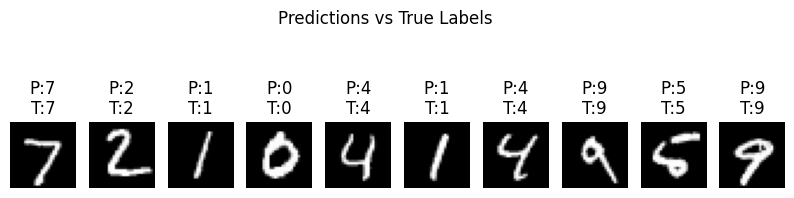

In [16]:
def show_predictions(model, loader):
    model.eval()
    batch = next(iter(loader))
    images = batch["image"][:10]
    labels = batch["label"][:10]

    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1)

    plt.figure(figsize=(10,3))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"P:{preds[i].item()}\nT:{labels[i].item()}")
        plt.axis("off")

    plt.suptitle("Predictions vs True Labels")
    plt.show()


show_predictions(model, test_loader)

Train MLP

In [17]:
print("\nTraining MLP Model...")
model = MLP()
optimizer = optim.Adam(model.parameters(), lr=0.001)

mlp_acc = 0

for epoch in range(5):
    loss = train(model, train_loader, optimizer, criterion)
    mlp_acc = test(model, test_loader)
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={mlp_acc:.2f}%")


Training MLP Model...
Epoch 1: Loss=0.6437, Acc=93.94%
Epoch 2: Loss=0.2689, Acc=95.46%
Epoch 3: Loss=0.2089, Acc=96.65%
Epoch 4: Loss=0.1818, Acc=96.79%
Epoch 5: Loss=0.1622, Acc=96.64%


Train Transformer

In [18]:
print("\nTraining Transformer Model...")
model = TransformerModel()
optimizer = optim.Adam(model.parameters(), lr=0.001)

trans_acc = 0

for epoch in range(5):
    loss = train(model, train_loader, optimizer, criterion)
    trans_acc = test(model, test_loader)
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={trans_acc:.2f}%")


Training Transformer Model...
Epoch 1: Loss=1.2132, Acc=82.17%
Epoch 2: Loss=0.6278, Acc=85.88%
Epoch 3: Loss=0.5038, Acc=90.35%
Epoch 4: Loss=0.4322, Acc=92.17%
Epoch 5: Loss=0.3869, Acc=92.93%


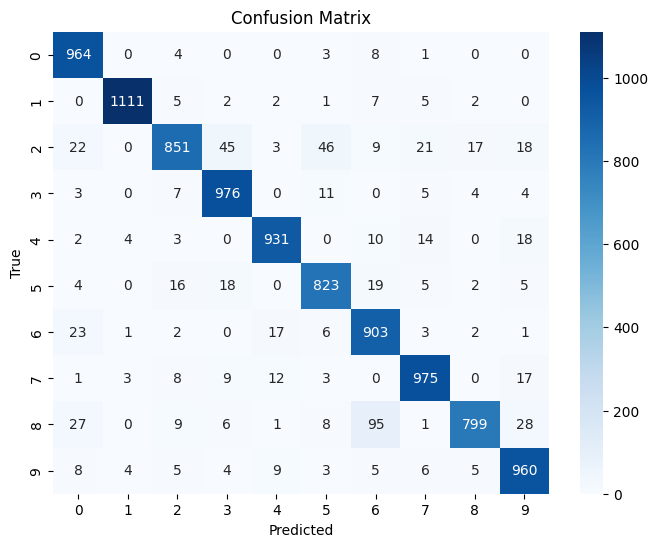

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            data = batch["image"]
            target = batch["label"]

            output = model(data)
            pred = output.argmax(dim=1)

            all_preds.extend(pred.numpy())
            all_labels.extend(target.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion_matrix(model, test_loader)

Final Comparison

In [20]:
print("\n=== Final Model Comparison ===")
print(f"MLP Accuracy        : {mlp_acc:.2f}%")
print(f"CNN Accuracy        : {cnn_acc:.2f}%")
print(f"Transformer Accuracy: {trans_acc:.2f}%")


=== Final Model Comparison ===
MLP Accuracy        : 96.64%
CNN Accuracy        : 99.00%
Transformer Accuracy: 92.93%


In [21]:
cnn_acc_list = []

for epoch in range(5):
    loss = train(model, train_loader, optimizer, criterion)
    acc = test(model, test_loader)

    cnn_acc_list.append(acc)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.2f}%")

Epoch 1: Loss=0.3629, Acc=93.73%
Epoch 2: Loss=0.3385, Acc=94.51%
Epoch 3: Loss=0.3211, Acc=94.85%
Epoch 4: Loss=0.3093, Acc=94.54%
Epoch 5: Loss=0.2945, Acc=94.89%


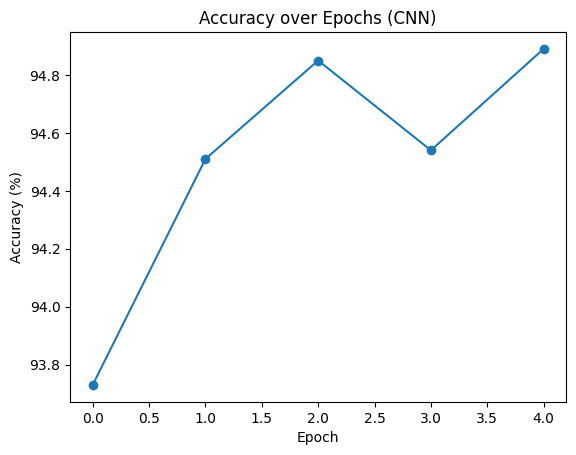

In [22]:
plt.plot(cnn_acc_list, marker='o')
plt.title("Accuracy over Epochs (CNN)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.show()